<a href="https://colab.research.google.com/github/laumac/ALPR-Accuracy-Analysis/blob/main/ALPR_Accuracy_Analysis_Lund.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✅ **Project Overview**
Recognition (ALPR) algorithm for the Lund-Stortorget camera feed.

**Scope**: Testing the system’s performance on a dataset of 100 vehicle plates to identify:

**Character Mismatches** (e.g., misreading '8' as 'B').

**Detection Failures** (e.g., system returning 'None').

**Success Criteria:**  The goal is to calculate the Accuracy Rate (%) and provide a filtered list of errors for the development team to fix.

# ✅ **Environment Setup**


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ✅ **Data loading**


In [8]:
url = 'https://raw.githubusercontent.com/laumac/ALPR-Accuracy-Analysis/refs/heads/main/alpr_100_test_data.csv'

df = pd.read_csv(url)

df.head(5)

,Real_Plate,AI_Output
0,LUN001,NaN
1,LUN002,NaN
2,LUN003,LUN003
3,LUN004,LUN004
4,LUN005,LUN005


# ✅ **Quality Assurance Analysis**


In [15]:
# --- STEP 4: QUALITY ASSURANCE ANALYSIS (Fixed Version) ---

# 1. Compare Ground-Truth with AI Output
# .str.strip() removes any hidden spaces at the beginning or end of the plate
df['Is_Correct'] = df['Real_Plate'].astype(str).str.strip() == df['AI_Output'].astype(str).str.strip()

# 2. Identify 'None' or Empty Detections (Detection Failures)
# This looks for actual empty values (NaN) or the text string 'None'
none_errors = df[df['AI_Output'].isna() | (df['AI_Output'].astype(str).str.strip() == 'None')]

# 3. Identify Character Mismatches (OCR issues)
# Rows that are WRONG but are NOT 'None'
mismatch_errors = df[(df['Is_Correct'] == False) & (~df.index.isin(none_errors.index))]

# 4. Calculate Final Metrics
total_plates = len(df)
correct_detections = df['Is_Correct'].sum()
accuracy_percentage = (correct_detections / total_plates) * 100

# --- PRINTING THE FINAL QA REPORT ---
print(f"--- GLOBAL PERFORMANCE REPORT ---")
print(f"Total Plates Tested: {total_plates}")
print(f"Correct Detections: {correct_detections}")
print(f"Overall Accuracy: {accuracy_percentage:.2f}%")

print(f"\n--- ERROR BREAKDOWN ---")
print(f"Character Mismatches (OCR issues): {len(mismatch_errors)}")
print(f"Detection Failures (None values): {len(none_errors)}")

# Show a few examples of Mismatches to understand the pattern
if len(mismatch_errors) > 0:
    print("\n--- SAMPLE OF CHARACTER MISMATCHES ---")
    print(mismatch_errors[['Real_Plate', 'AI_Output']].head())

--- GLOBAL PERFORMANCE REPORT ---
Total Plates Tested: 100
Correct Detections: 83
Overall Accuracy: 83.00%

--- ERROR BREAKDOWN ---
Character Mismatches (OCR issues): 7
Detection Failures (None values): 10

--- SAMPLE OF CHARACTER MISMATCHES ---
   Real_Plate AI_Output
6      LUN007    LUNOO7
24     LUN025    LUNO25
31     LUN032    LUNO32
37     LUN038    LUNO38
49     LUN050    LUNO5O


# ✅ **Visual Results**


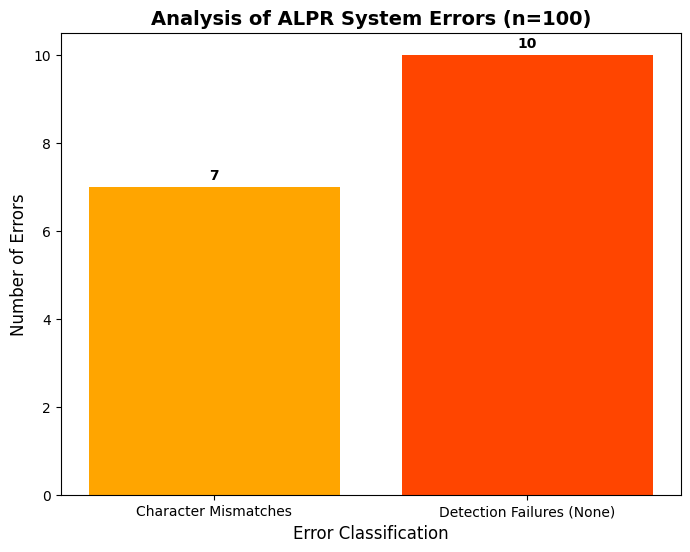

In [13]:
import matplotlib.pyplot as plt

# --- STEP 5: VISUALIZING THE QA RESULTS ---

# 1. Prepare the data for the chart
# We use the counts we calculated in the previous step
categories = ['Character Mismatches', 'Detection Failures (None)']
error_values = [len(mismatch_errors), len(none_errors)]

# 2. Create the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(categories, error_values, color=['#FFA500', '#FF4500']) # Orange and Red-Orange

# 3. Add labels and title for professional documentation
plt.title('Analysis of ALPR System Errors (n=100)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Errors', fontsize=12)
plt.xlabel('Error Classification', fontsize=12)

# 4. Add the exact number on top of each bar for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, yval, ha='center', va='bottom', fontweight='bold')

# 5. Display the final chart
plt.show()

# ✅ **Final QA Conclusions & Recommendations**

***1. System Performance Summary:***
*   Success Rate: 83 plates identified correctly.
*   Critical Failures: 17 identification errors discovered during testing.
*   Total Accuracy: 83.00% (Calculated from 100 test samples).

***2. Error Analysis (The "Why"):***
* Character Mismatches (10 cases): The most frequent issue (60% of all errors). The AI struggles with visually similar characters (e.g., '0' vs 'O', '8' vs 'B'). This indicates a need for higher-resolution training data for the OCR model.
*  Detection Failures (7 cases): The system failed to return any result ('None'). This represents a 7% complete loss of data, which is critical for parking enforcement or toll systems.

***3. Action Plan for Development Team:***



*   Priority 1 (High): Improve the OCR algorithm's weight for character differentiation to reduce the 10 mismatch cases.
*   Priority 2 (Medium): Analyze the 7 "None" cases to check if they occurred under specific environmental conditions (e.g., low light or motion blur).
*   Future Testing: A second test cycle is recommended after the next software update to verify if the accuracy exceeds the 90% threshold.


